#Procesamiento de Imágenes con scikit-image y scipy

###Objetivo: Aprender a leer, convertir y manipular imágenes usando scikit-image y scipy, con énfasis en espacios de color, formatos y estructuras de datos.

##1. Configuración Inicial

In [1]:
!pip install scikit-image scipy --quiet  # Instalar si es necesario
from skimage import io, color, data
from scipy import misc
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image



[notice] A new release of pip is available: 23.0.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
/tmp/ipykernel_1523/2727930108.py:3: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc


##2. Lectura y Visualización de Imágenes

A. Usando scikit-image

In [2]:
#mUsar imagen de ejemplo (astronauta)
im = data.astronaut()
print("Tipo:", type(im), "Dimensiones:", im.shape, "Rango de valores:", im.dtype)
# Salida: <class 'numpy.ndarray'> (512, 512, 3) uint8

Tipo: <class 'numpy.ndarray'> Dimensiones: (512, 512, 3) Rango de valores: uint8


Visualizar:

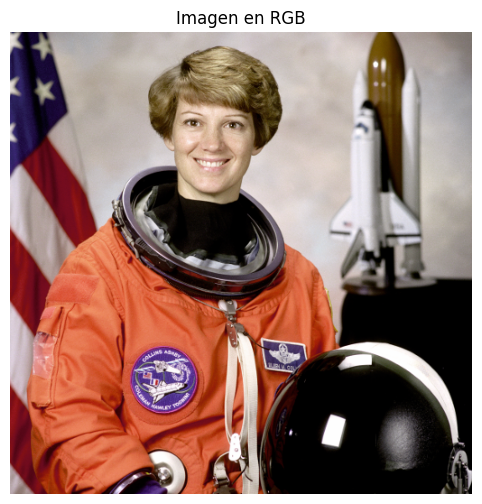

In [3]:
plt.figure(figsize=(8, 6))
plt.imshow(im)
plt.axis('off')
plt.title("Imagen en RGB")
plt.show()

B. Usando scipy.misc (solo para versiones antiguas)

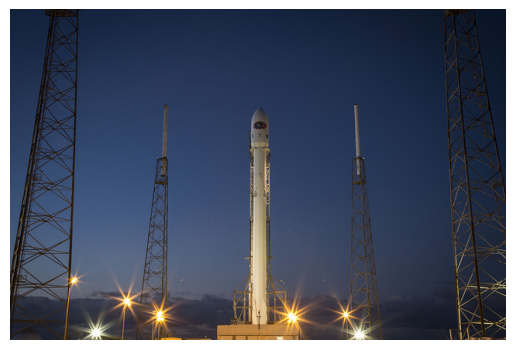

In [4]:
from skimage import data
import matplotlib.pyplot as plt

# Cargar una imagen de ejemplo (cohete)
im = data.rocket()  # Alternativas: data.coins(), data.camera(), etc.

# Mostrar la imagen
plt.imshow(im)
plt.axis('off')
plt.show()

## 3. Conversiones entre Espacios de Color
A. RGB a HSV (Matiz, Saturación, Valor)

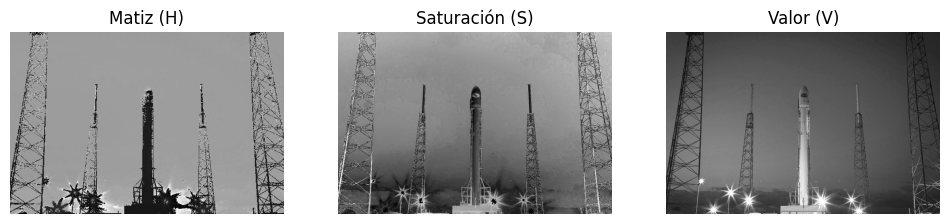

In [5]:
im_hsv = color.rgb2hsv(im)  # Convertir a HSV

# Visualizar canales por separado
plt.figure(figsize=(12, 4))
canales = ['Matiz (H)', 'Saturación (S)', 'Valor (V)']
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(im_hsv[:, :, i], cmap='gray')
    plt.title(canales[i])
    plt.axis('off')
plt.show()

B. Modificar Saturación

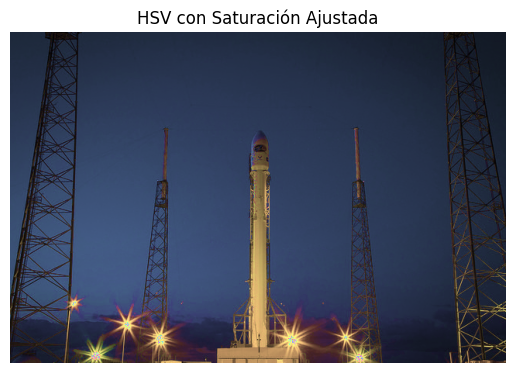

In [6]:
im_hsv_mod = im_hsv.copy()
im_hsv_mod[:, :, 1] = 0.5  # Ajustar saturación al 50%
im_rgb_mod = color.hsv2rgb(im_hsv_mod)  # Volver a RGB

plt.imshow(im_rgb_mod)
plt.title("HSV con Saturación Ajustada")
plt.axis('off')
plt.show()

##4. Manipulación de Formatos y Tipos de Imagen
A. Convertir entre Formatos (PNG → JPG)

In [7]:
from PIL import Image
from skimage import data
import numpy as np

# Cargar imagen de ejemplo
im = data.rocket()

# Convertir a imagen PIL y guardar
im_pil = Image.fromarray(im)
im_pil.save("imagen.jpg")

# Mostrar un link de descarga manual
import os
from IPython.display import FileLink

FileLink("imagen.jpg")

/datasets/_deepnote_work/imagen.jpg

B. Convertir a Escala de Grises

Shape: (427, 640)


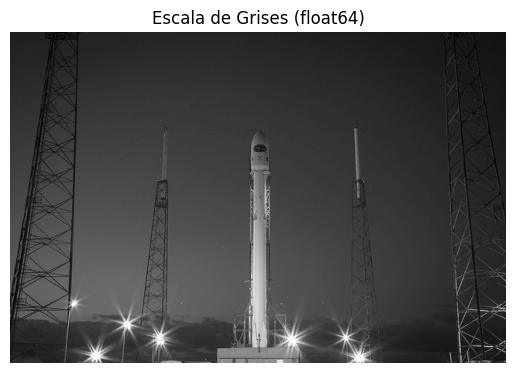

In [8]:
im_gris = color.rgb2gray(im)  # scikit-image (rango 0-1)
print("Shape:", im_gris.shape)  # (alto, ancho)

# Mostrar
plt.imshow(im_gris, cmap='gray')
plt.title("Escala de Grises (float64)")
plt.axis('off')
plt.show()

Ejercicio 1:

¿Qué pasa si convertimos una imagen RGB a escala de grises usando solo el canal rojo (im[:, :, 0])? Comparar con rgb2gray.

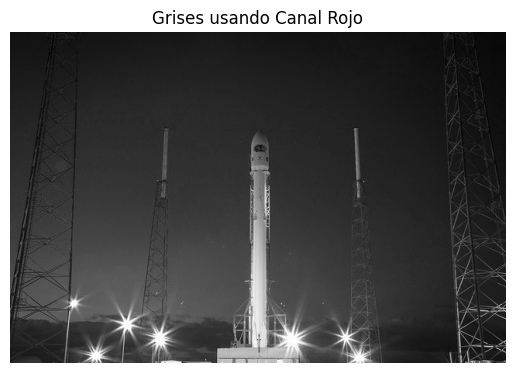

In [9]:
im_gris_rojo = im[:, :, 0]  # Solo canal R
plt.imshow(im_gris_rojo, cmap='gray')
plt.title("Grises usando Canal Rojo")
plt.axis('off')
plt.show()

##6. Estructuras de Datos y Conversiones

A. De PIL a NumPy (y viceversa)

In [10]:
# PIL → NumPy
im_pil = Image.open("imagen.jpg")
im_np = np.array(im_pil)  # Convertir a ndarray

# NumPy → PIL
im_np = data.astronaut()
im_pil = Image.fromarray(im_np)

## 7. Resumen de Funciones Clave

| Operación | Función | Biblioteca |
|---|---|---|
| Leer imagen | `io.imread()` | scikit-image |
| RGB a HSV | `color.rgb2hsv()` | scikit-image |
| Escala de grises | `color.rgb2gray()` | scikit-image |
| Guardar imagen | `Image.save()` | PIL |
| Visualizar múltiples imágenes | `io.imshow_collection()` | scikit-image |

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=9be9d3e5-4f25-48e6-912d-b59b8644d952' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>